# Day 3 - Exploratory Data Analysis

Objectives:
- Analyze NAV trends
- Analyze SIP inflows
- Study investor demographics
- Examine AUM growth
- Analyze sector allocations
- Generate actionable insights

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("default")

sns.set_theme(style="whitegrid")

In [39]:
from pathlib import Path

charts_dir = Path("../reports/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

print("Charts folder created")

Charts folder created


In [40]:
# Plotly Charts

fig.write_image(charts_dir / "01_nav_trend.png")

fig.write_image(charts_dir / "02_sip_inflow_trend.png")

fig.write_image(charts_dir / "12_sector_allocation_donut.png")

In [41]:
fund_df = pd.read_csv("../data/processed/clean_fund_master.csv")

nav_df = pd.read_csv("../data/processed/clean_nav_history.csv")

aum_df = pd.read_csv("../data/processed/clean_aum_by_fund_house.csv")

sip_df = pd.read_csv("../data/processed/clean_monthly_sip_inflows.csv")

cat_df = pd.read_csv("../data/processed/clean_category_inflows.csv")

folio_df = pd.read_csv("../data/processed/clean_industry_folio_count.csv")

perf_df = pd.read_csv("../data/processed/clean_scheme_performance.csv")

tx_df = pd.read_csv("../data/processed/clean_investor_transactions.csv")

portfolio_df = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")

benchmark_df = pd.read_csv("../data/processed/clean_benchmark_indices.csv")

In [42]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [43]:
fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.show()

In [44]:
fig.write_image(
    "../reports/nav_trend.png"
)


# AUM Growth by Fund House

In [45]:
print(aum_df.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


In [46]:
aum_df["date"] = pd.to_datetime(aum_df["date"])

aum_df["year"] = aum_df["date"].dt.year

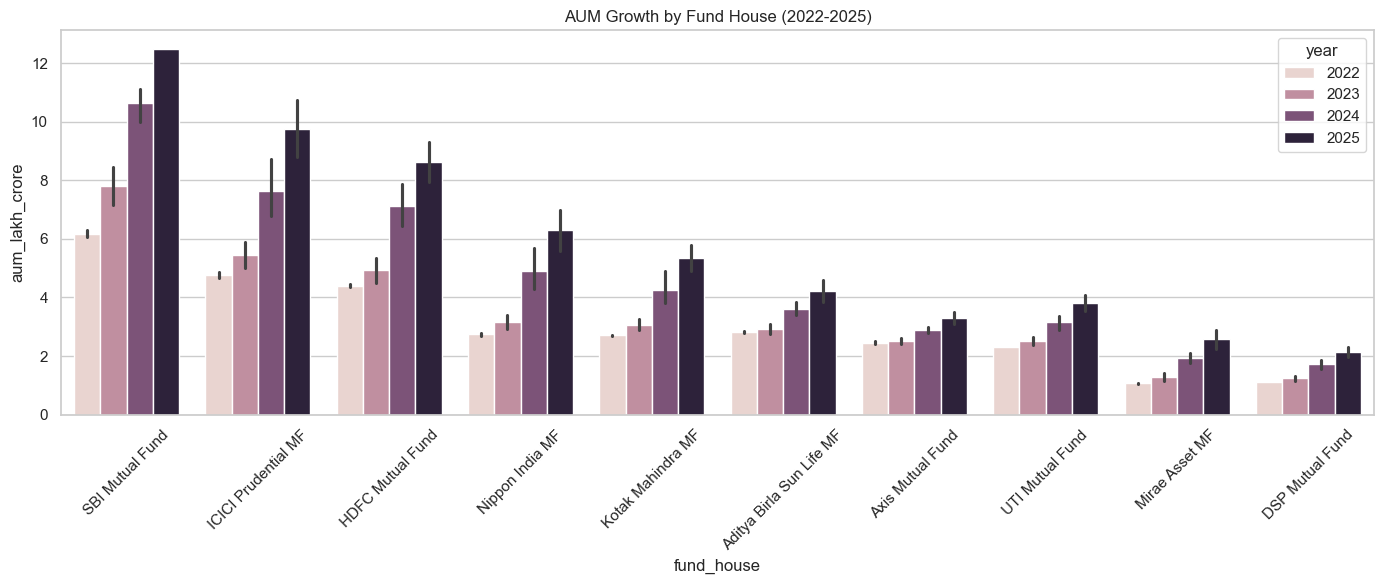

In [47]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_df,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=45)
plt.title("AUM Growth by Fund House (2022-2025)")
plt.tight_layout()

plt.show()

In [48]:
plt.savefig(
    "../reports/aum_growth.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# SIP Inflow Trend

In [49]:
sip_df["month"] = pd.to_datetime(
    sip_df["month"]
)

fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend"
)

fig.show()

In [50]:
sip_df["month"] = pd.to_datetime(
    sip_df["month"]
)

peak = sip_df.loc[
    sip_df["sip_inflow_crore"].idxmax()
]

fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend"
)

fig.add_annotation(
    x=peak["month"],
    y=peak["sip_inflow_crore"],
    text=f"Peak: ₹{peak['sip_inflow_crore']:,} Cr"
)

fig.show()

# Category Inflow Heatmap

In [51]:
print(cat_df.columns)
print(cat_df.head())

Index(['month', 'category', 'net_inflow_crore'], dtype='object')
        month         category  net_inflow_crore
0  2024-04-01        Large Cap            2413.0
1  2024-04-01          Mid Cap            3897.0
2  2024-04-01        Small Cap            3533.0
3  2024-04-01        Flexi Cap            4947.0
4  2024-04-01  Large & Mid Cap            4214.0


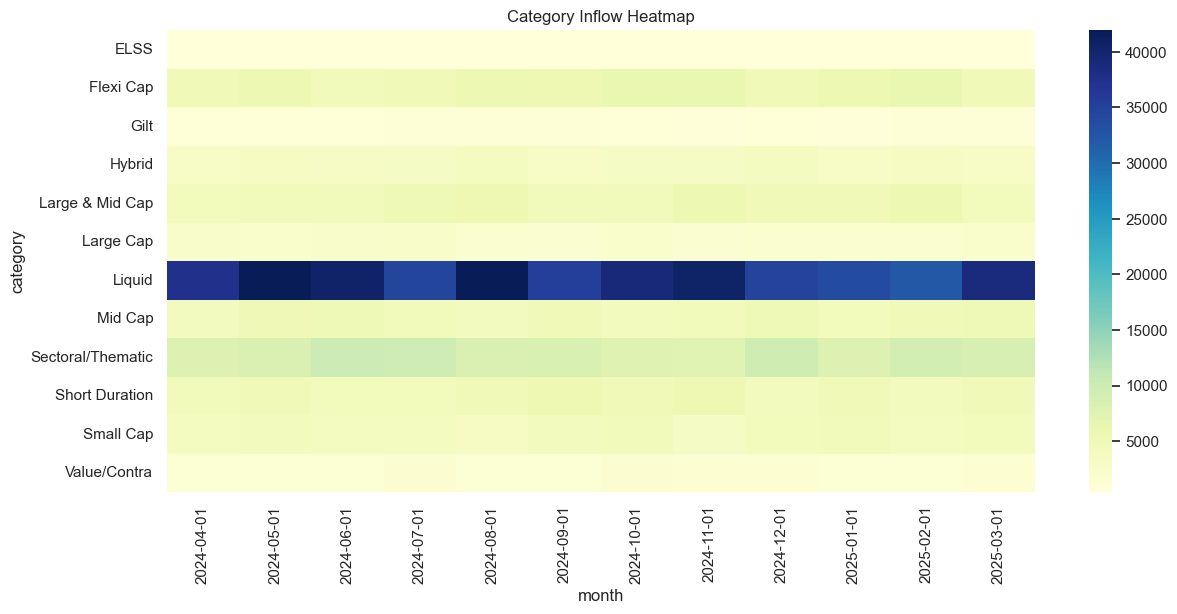

In [52]:
heatmap_df = cat_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_df,
    cmap="YlGnBu"
)

plt.title(
    "Category Inflow Heatmap"
)

plt.show()

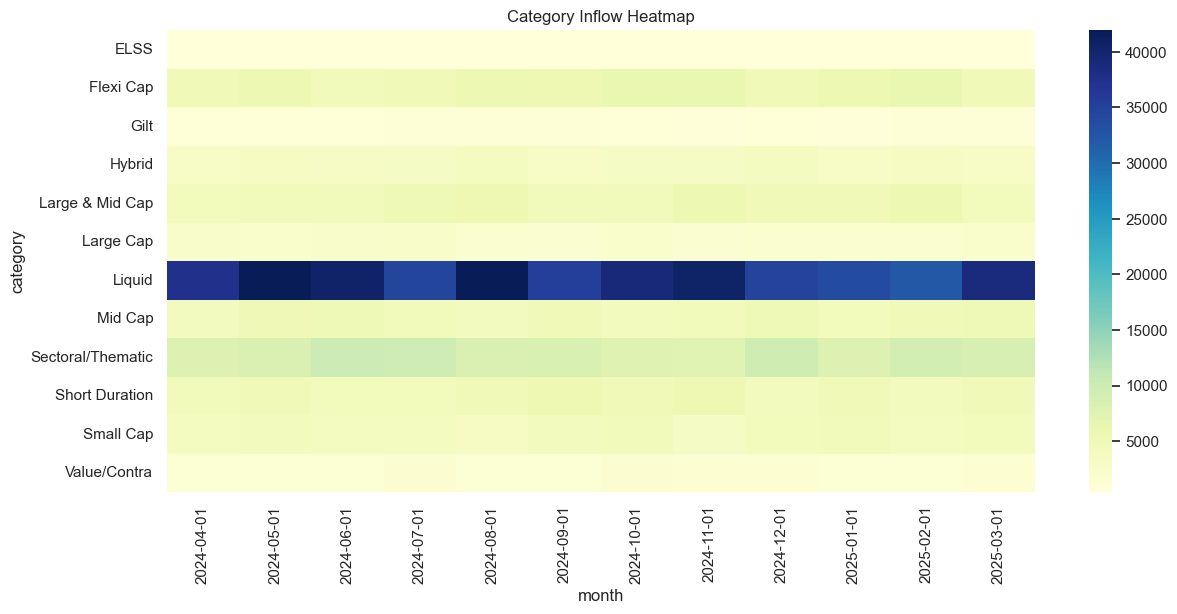

In [53]:
heatmap_df = cat_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_df,
    cmap="YlGnBu"
)

plt.title(
    "Category Inflow Heatmap"
)

plt.show()

# Age Group Distribution

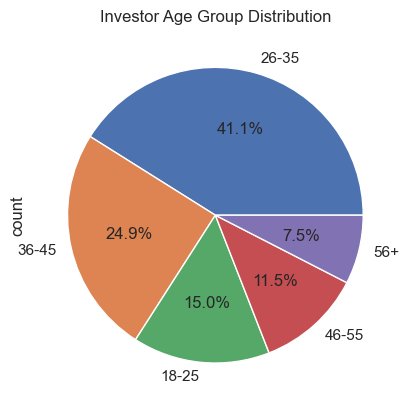

In [54]:
tx_df["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "Investor Age Group Distribution"
)

plt.show()

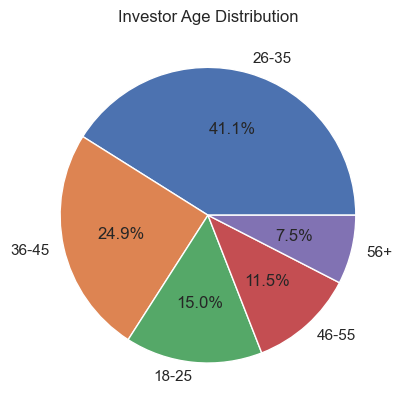

In [55]:
tx_df["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "Investor Age Distribution"
)

plt.ylabel("")

plt.show()

In [56]:
print(aum_df.columns.tolist())

print(cat_df.columns.tolist())

print(portfolio_df.columns.tolist())

print(folio_df.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes', 'year']
['month', 'category', 'net_inflow_crore']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


# SIP Amount Box Plot by Age

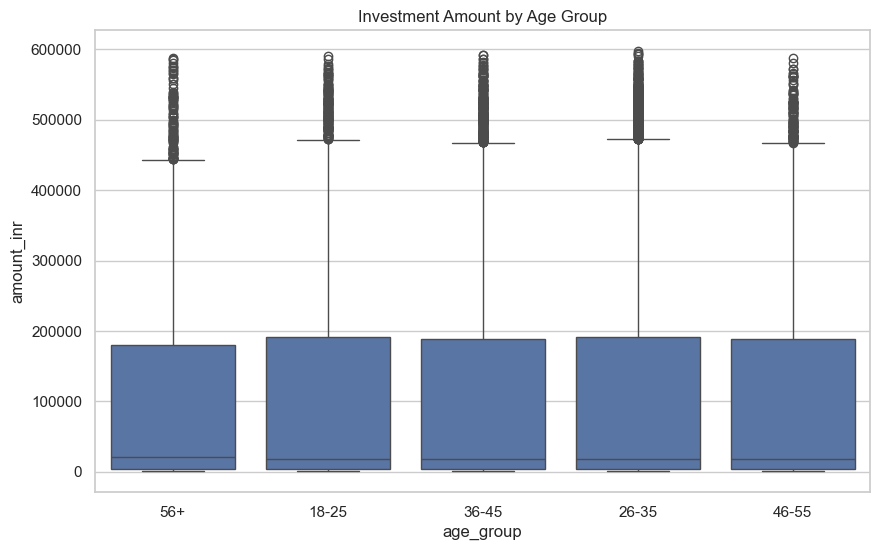

In [57]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=tx_df,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "Investment Amount by Age Group"
)

plt.show()

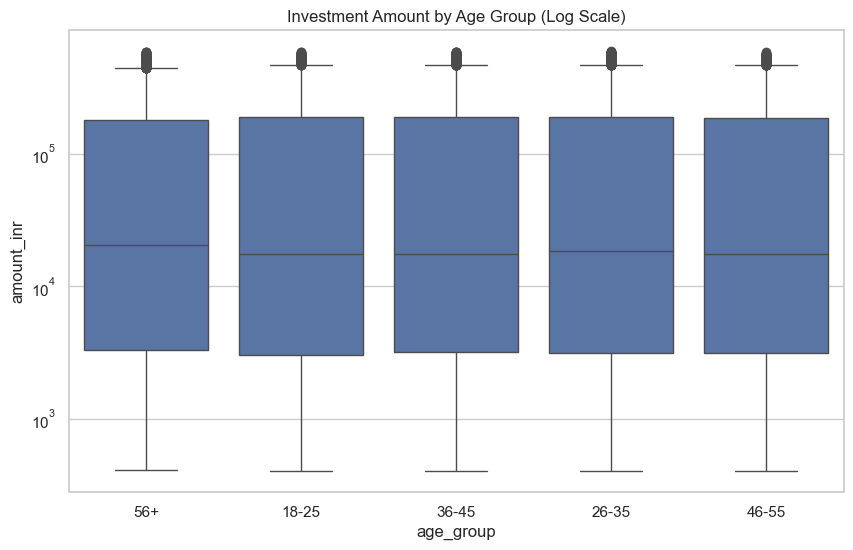

In [58]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=tx_df,
    x="age_group",
    y="amount_inr"
)

plt.yscale("log")

plt.title(
    "Investment Amount by Age Group (Log Scale)"
)

plt.show()

# Gender split

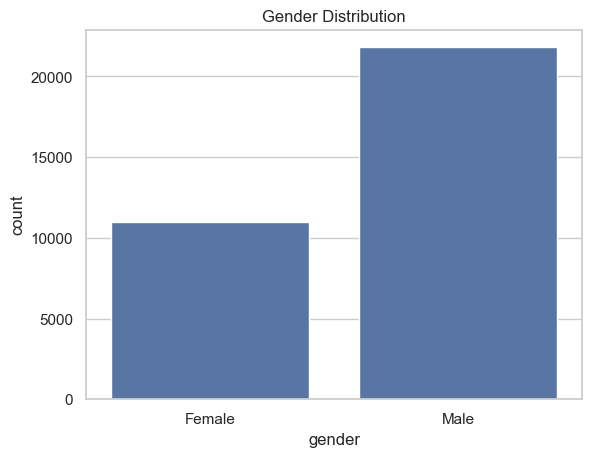

In [59]:
sns.countplot(
    data=tx_df,
    x="gender"
)

plt.title(
    "Gender Distribution"
)

plt.show()

# SIP Amount by State

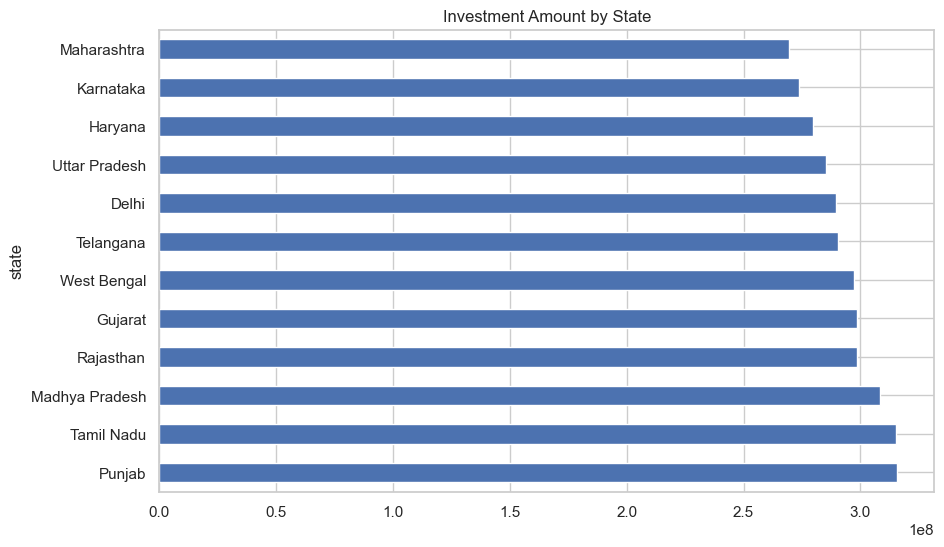

In [60]:
state_amount = (
    tx_df.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

state_amount.plot(
    kind="barh"
)

plt.title(
    "Investment Amount by State"
)

plt.show()

# T30 vs B30

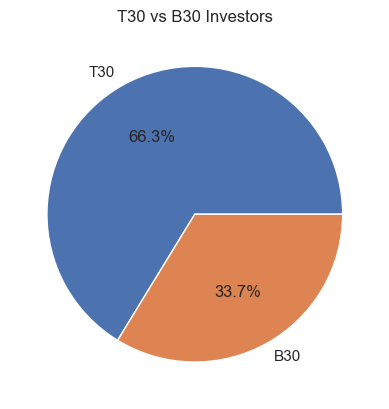

In [61]:
tx_df["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "T30 vs B30 Investors"
)

plt.ylabel("")

plt.show()

# Folio Growth

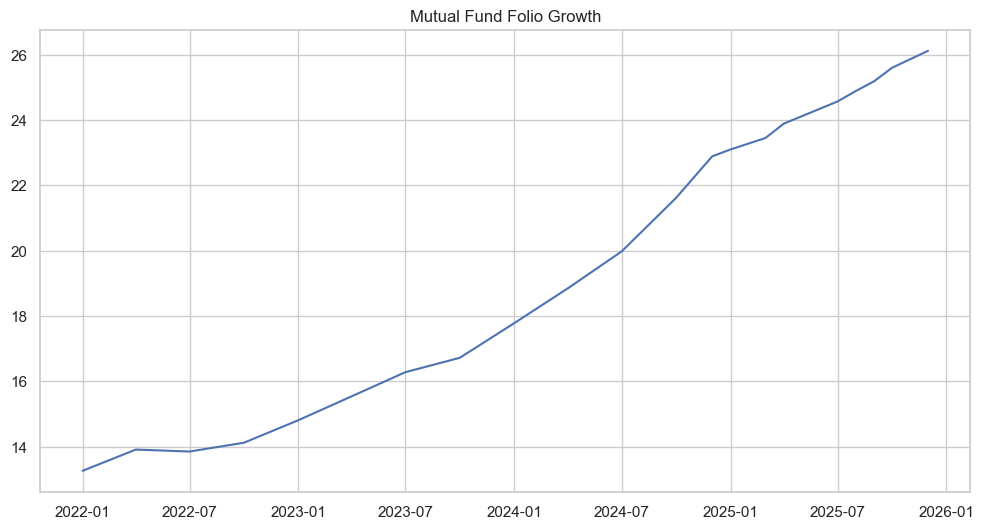

In [62]:
folio_df["month"] = pd.to_datetime(
    folio_df["month"]
)

plt.figure(figsize=(12,6))

plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"]
)

plt.title(
    "Mutual Fund Folio Growth"
)

plt.show()

# Correlation Matrix

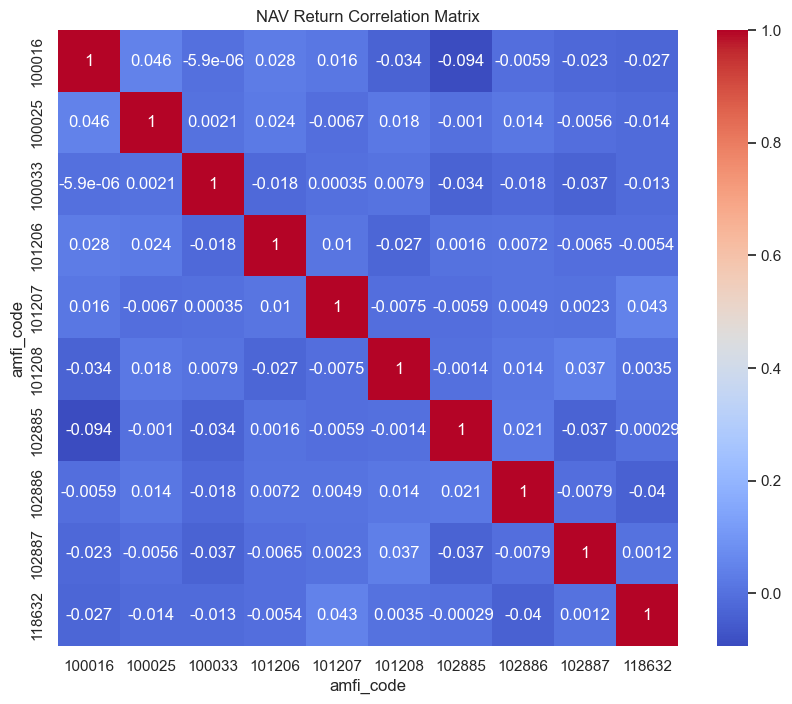

In [63]:
nav_df["date"] = pd.to_datetime(
    nav_df["date"]
)

sample_funds = (
    nav_df["amfi_code"]
    .unique()[:10]
)

corr_df = nav_df[
    nav_df["amfi_code"].isin(sample_funds)
]

pivot = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "NAV Return Correlation Matrix"
)

plt.show()

# Sector Allocation Donut

In [64]:
sector_weights = (
    portfolio_df.groupby("sector")
    ["weight_pct"]
    .sum()
)

fig = px.pie(
    values=sector_weights.values,
    names=sector_weights.index,
    hole=0.5,
    title="Sector Allocation"
)

fig.show()

# Top 10 Funds by AUM

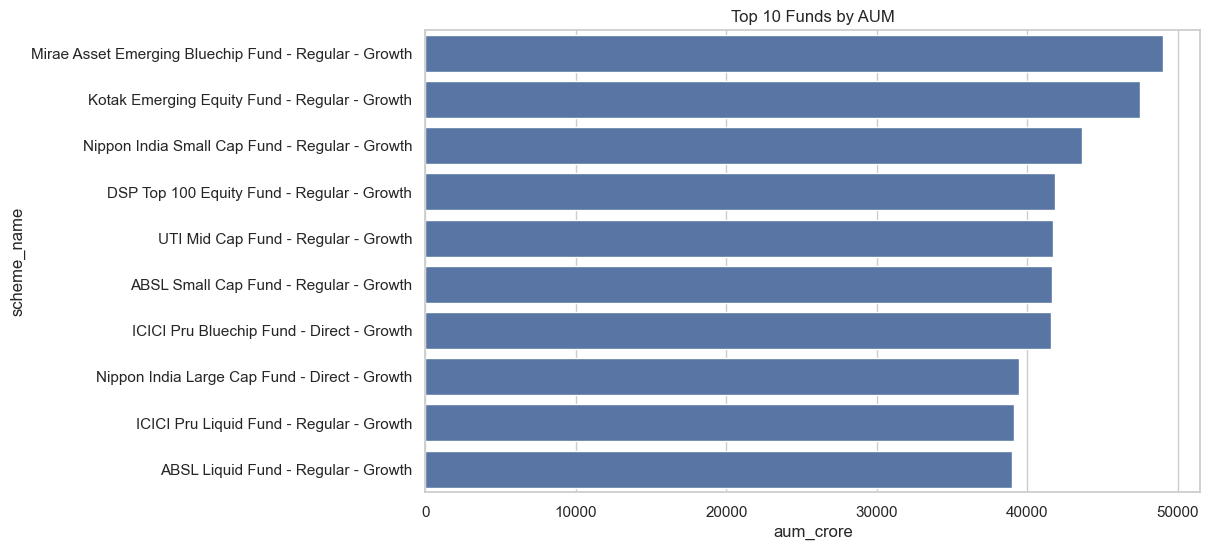

In [65]:
top_aum = (
    perf_df.sort_values(
        "aum_crore",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_aum,
    x="aum_crore",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds by AUM"
)

plt.show()

# Expense Ratio Distribution

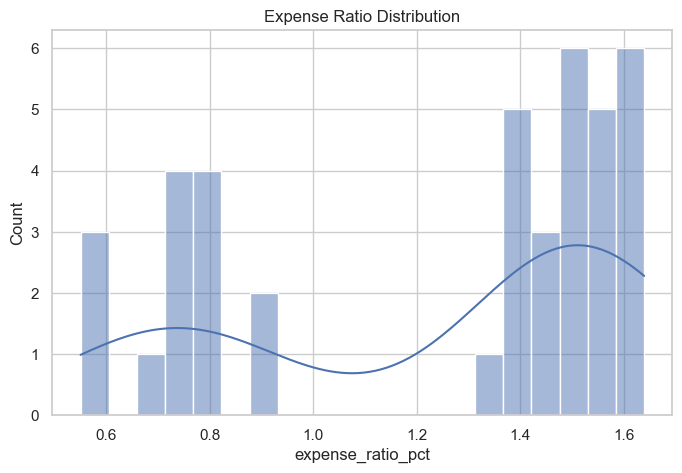

In [66]:
plt.figure(figsize=(8,5))

sns.histplot(
    perf_df["expense_ratio_pct"],
    bins=20,
    kde=True
)

plt.title(
    "Expense Ratio Distribution"
)

plt.show()

# Sharpe Ratio by Category

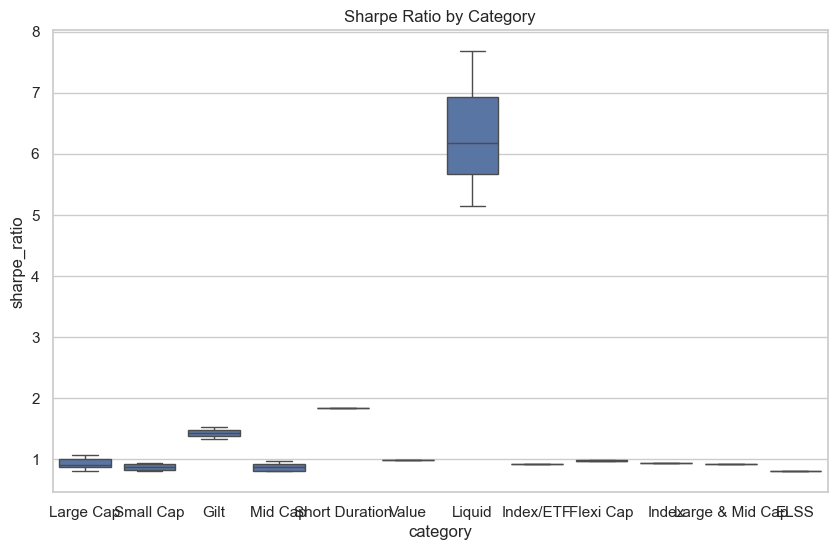

In [67]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=perf_df,
    x="category",
    y="sharpe_ratio"
)

plt.title(
    "Sharpe Ratio by Category"
)

plt.show()

### Insight 1
NAV values exhibited a consistent upward trend between 2022 and 2026, indicating long-term growth across most mutual fund schemes.

### Insight 2
Several equity-oriented schemes experienced accelerated NAV growth during the 2023 market rally.

### Insight 3
SBI Mutual Fund maintained one of the highest AUM levels among all fund houses throughout the analysis period.

### Insight 4
Monthly SIP inflows demonstrated strong growth from 2022 to 2025, reflecting increasing retail investor participation.

### Insight 5
Large Cap, Flexi Cap, and Mid Cap categories consistently attracted strong net inflows compared to other categories.

### Insight 6
The 26–35 and 36–45 age groups represented the largest share of mutual fund investors.

### Insight 7
T30 cities contributed a significantly larger proportion of investment activity compared to B30 cities.

### Insight 8
Total folio counts increased substantially between 2022 and 2025, indicating sustained growth in investor accounts.

### Insight 9
Most selected funds showed positive correlations in daily returns, reflecting common exposure to broader market movements.

### Insight 10
Portfolio allocations were concentrated in a small number of dominant sectors, indicating sector-specific investment preferences.

In [68]:
plt.savefig(
    charts_dir / "03_aum_growth.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    charts_dir / "04_category_heatmap.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    charts_dir / "05_age_group_pie.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    charts_dir / "06_sip_boxplot_age.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    charts_dir / "07_gender_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    charts_dir / "08_state_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    charts_dir / "09_city_tier_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    charts_dir / "10_folio_growth.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    charts_dir / "11_correlation_matrix.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    charts_dir / "13_top_funds_aum.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    charts_dir / "14_expense_ratio_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    charts_dir / "15_sharpe_ratio_category.png",
    bbox_inches="tight",
    dpi=300
)

<Figure size 640x480 with 0 Axes>

In [69]:
from pathlib import Path

charts = list(Path("../reports/charts").glob("*.png"))

print(f"Total Charts Exported: {len(charts)}")

for chart in charts:
    print(chart.name)

Total Charts Exported: 15
01_nav_trend.png
02_sip_inflow_trend.png
03_aum_growth.png
04_category_heatmap.png
05_age_group_pie.png
06_sip_boxplot_age.png
07_gender_distribution.png
08_state_distribution.png
09_city_tier_distribution.png
10_folio_growth.png
11_correlation_matrix.png
12_sector_allocation_donut.png
13_top_funds_aum.png
14_expense_ratio_distribution.png
15_sharpe_ratio_category.png
